In [8]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import os

In [9]:
data_location = 'archive/PlantVillage'
img_height = 224
img_width = 224
batch_size = 32

In [11]:
data_augmentation = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [12]:
validation_data = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [17]:
training_dataset = data_augmentation.flow_from_directory(
    data_location,
    target_size=(img_height, img_width),
    batch_size = batch_size,
    class_mode='categorical',
    subset='training'
)

Found 16516 images belonging to 15 classes.


In [16]:
validation_generator = data_augmentation.flow_from_directory(
    data_location,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4122 images belonging to 15 classes.


In [20]:
numbers_of_classes = len(training_dataset.class_indices)
detected_classes = list(training_dataset.class_indices.keys())
print(f"Detected {numbers_of_classes} \n\nclasses: {detected_classes}")

Detected 15 

classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [22]:
for x, y in training_dataset:
    print(f"Sample batch label shape: {y.shape}")
    print(f"Sample batch label values: {y[:5]}")
    break

Sample batch label shape: (32, 15)
Sample batch label values: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


In [25]:
print(f"Loaded {training_dataset.samples} train images, {validation_generator.samples} val images across {numbers_of_classes} classes.")

Loaded 16516 train images, 4122 val images across 15 classes.


In [29]:
model = models.Sequential([
    layers.Conv2D(32, (3,3),activation='relu', input_shape=(img_height, img_width,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(numbers_of_classes, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
trained_model = model.fit(
    training_dataset,
    steps_per_epoch=training_dataset.samples//batch_size,
    validation_data=validation_generator,
    validation_steps= validation_generator.samples//batch_size,
    epochs=10
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 533s 1s/step - accuracy: 0.3844 - loss: 1.9356 - val_accuracy: 0.5911 - val_loss: 1.3198
Epoch 2/10
  1/516 ━━━━━━━━━━━━━━━━━━━━ 3:55 457ms/step - accuracy: 0.6875 - loss: 1.2978

C:\Users\Admin\Documents\vegtableProject\mlenvTensor\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


516/516 ━━━━━━━━━━━━━━━━━━━━ 45s 86ms/step - accuracy: 0.6875 - loss: 1.2978 - val_accuracy: 0.5615 - val_loss: 1.3849
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 390s 756ms/step - accuracy: 0.5789 - loss: 1.2807 - val_accuracy: 0.6909 - val_loss: 0.9196
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.6875 - loss: 0.9305 - val_accuracy: 0.6863 - val_loss: 0.9157
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 423s 819ms/step - accuracy: 0.6440 - loss: 1.0637 - val_accuracy: 0.7485 - val_loss: 0.7514
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 54s 103ms/step - accuracy: 0.5312 - loss: 1.2444 - val_accuracy: 0.7405 - val_loss: 0.7724
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 422s 817ms/step - accuracy: 0.6915 - loss: 0.9302 - val_accuracy: 0.8120 - val_loss: 0.5688
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 52s 100ms/step - accuracy: 0.6875 - loss: 0.6660 - val_accuracy: 0.8147 - val_loss: 0.5531
Epoch 9/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 417s 807ms/step - accuracy: 0.7251 - loss: 0.8173 - 

In [35]:
validation_generator.reset()
y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = validation_generator.classes
val_acc = accuracy_score(y_true, y_pred_classes)
print(f"Validation Accuracy: {val_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=detected_classes))

129/129 ━━━━━━━━━━━━━━━━━━━━ 40s 312ms/step
Validation Accuracy: 0.0837

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.06      0.08      0.07       199
                     Pepper__bell___healthy       0.07      0.08      0.07       295
                      Potato___Early_blight       0.05      0.06      0.06       200
                       Potato___Late_blight       0.05      0.03      0.04       200
                           Potato___healthy       0.00      0.00      0.00        30
                      Tomato_Bacterial_spot       0.10      0.12      0.11       425
                        Tomato_Early_blight       0.04      0.02      0.03       200
                         Tomato_Late_blight       0.09      0.09      0.09       381
                           Tomato_Leaf_Mold       0.05      0.05      0.05       190
                  Tomato_Septoria_leaf_spot       0.0

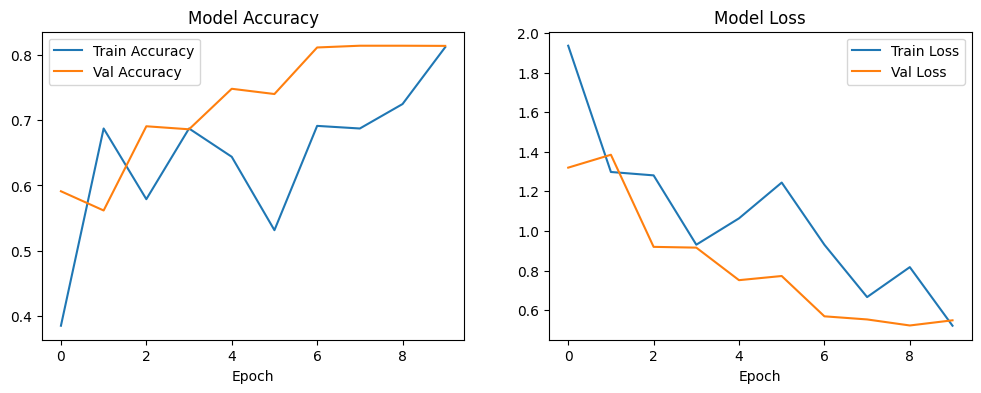

In [37]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(trained_model.history['accuracy'], label='Train Accuracy')
plt.plot(trained_model.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(trained_model.history['loss'], label='Train Loss')
plt.plot(trained_model.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [39]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)
class_names = [
    'Pepper__bell___Bacterial_spot',
    'Pepper__bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

img_path = "archive/PlantVillage/Pepper__bell___Bacterial_spot/00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Spot 3132.jpg"  # change this

img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

pred = model.predict(img_array)
pred_probs = tf.nn.softmax(pred[0]).numpy()
pred_index = np.argmax(pred_probs)
pred_class = class_names[pred_index]
confidence = pred_probs[pred_index]

print("Predicted class:", pred_class)
print("Confidence:", float(confidence))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted class: Pepper__bell___Bacterial_spot
Confidence: 0.16259336471557617


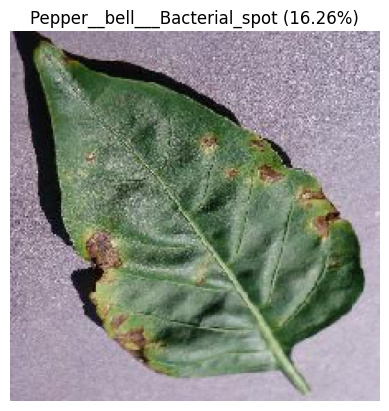

In [40]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")
plt.title(f"{pred_class} ({confidence:.2%})")
plt.show()


In [41]:
import numpy as np
import tensorflow as tf

pred = model.predict(img_array)
probs = tf.nn.softmax(pred[0]).numpy()

top_k = 5
top_indices = probs.argsort()[-top_k:][::-1]

for i in top_indices:
    print(f"{class_names[i]:50s} -> {probs[i]*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Pepper__bell___Bacterial_spot                      -> 16.26%
Tomato__Tomato_mosaic_virus                        -> 5.98%
Tomato_healthy                                     -> 5.98%
Tomato__Target_Spot                                -> 5.98%
Tomato_Spider_mites_Two_spotted_spider_mite        -> 5.98%


In [43]:
val_loss, val_acc = model.evaluate(validation_generator)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 37s 288ms/step - accuracy: 0.8197 - loss: 0.5339
Validation loss: 0.5339
Validation accuracy: 0.8197


In [53]:
model_version = 1
model_dir = "./models"
os.makedirs(model_dir, exist_ok=True)

model.save(f"{model_dir}/model_v{model_version}.keras")